In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os

# Better looking plots
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [11]:
df = pd.read_csv("../data/superstore_cleaned.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.960
1,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620
2,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.368
3,6,CA-2015-115812,2015-06-09,2015-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860
4,7,CA-2015-115812,2015-06-09,2015-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.280


In [12]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8655 entries, 0 to 8654
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         8655 non-null   int64  
 1   Order ID       8655 non-null   object 
 2   Order Date     8655 non-null   object 
 3   Ship Date      8655 non-null   object 
 4   Ship Mode      8655 non-null   object 
 5   Customer ID    8655 non-null   object 
 6   Customer Name  8655 non-null   object 
 7   Segment        8655 non-null   object 
 8   Country        8655 non-null   object 
 9   City           8655 non-null   object 
 10  State          8655 non-null   object 
 11  Postal Code    8655 non-null   float64
 12  Region         8655 non-null   object 
 13  Product ID     8655 non-null   object 
 14  Category       8655 non-null   object 
 15  Sub-Category   8655 non-null   object 
 16  Product Name   8655 non-null   object 
 17  Sales          8655 non-null   float64
dtypes: float

,Row ID,Postal Code,Sales
count,8655.000000,8655.000000,8655.000000
mean,4916.320508,55443.406355,93.213330
std,2830.949018,31957.075620,114.693292
min,1.000000,1040.000000,0.444000
25%,2454.500000,23320.000000,15.014000
50%,4925.000000,60067.000000,40.880000
75%,7362.500000,90004.000000,124.382000
max,9800.000000,99301.000000,500.240000


In [15]:
os.makedirs("../visualizations", exist_ok=True)

In [14]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

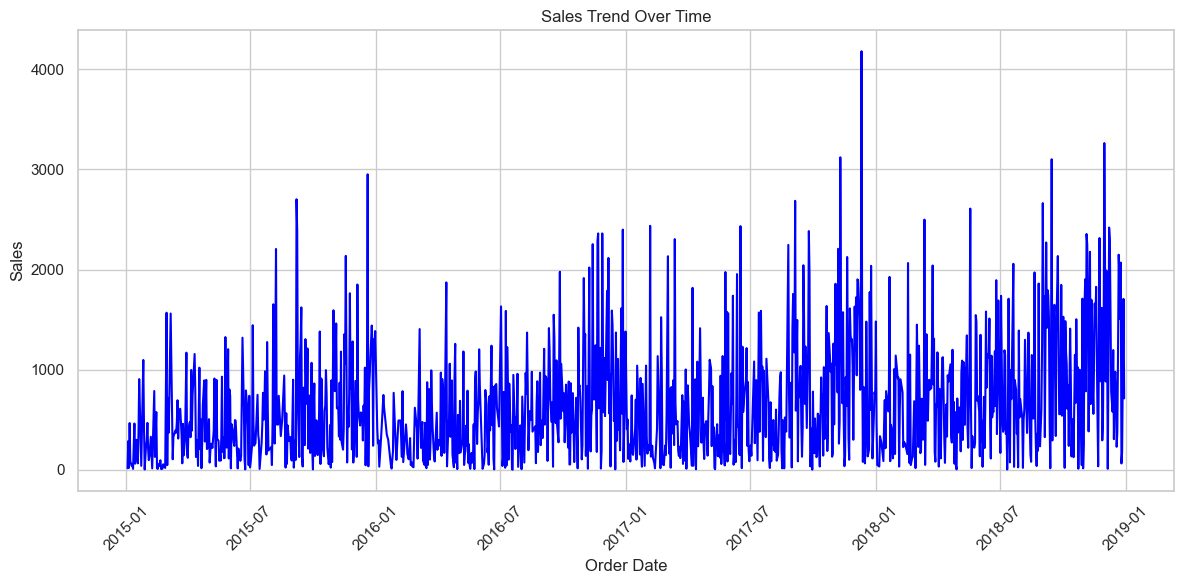

In [16]:
# Group sales by Order Date
sales_trend = df.groupby("Order Date")["Sales"].sum().reset_index()

plt.figure(figsize=(12,6))
plt.plot(sales_trend["Order Date"], sales_trend["Sales"], color="blue")
plt.title("Sales Trend Over Time")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()

# Save the figure
plt.savefig("../visualizations/line_chart.png")

plt.show()

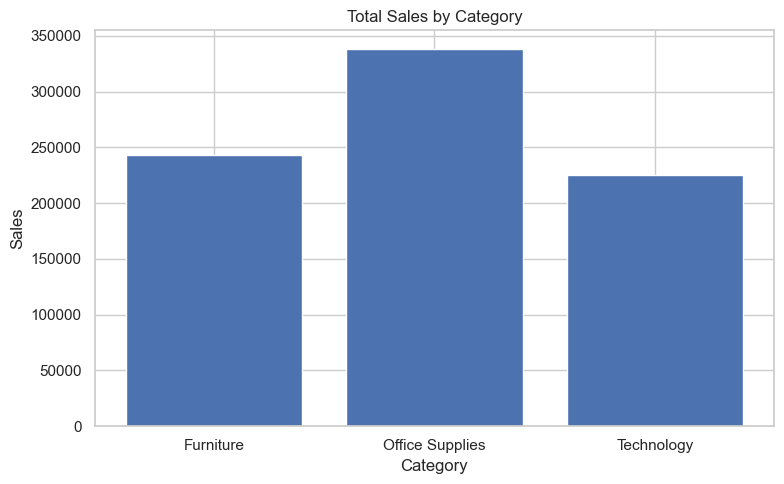

In [17]:
category_sales = df.groupby("Category")["Sales"].sum().reset_index()

plt.figure(figsize=(8,5))
plt.bar(category_sales["Category"], category_sales["Sales"])
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.tight_layout()

plt.savefig("../visualizations/bar_chart.png")

plt.show()

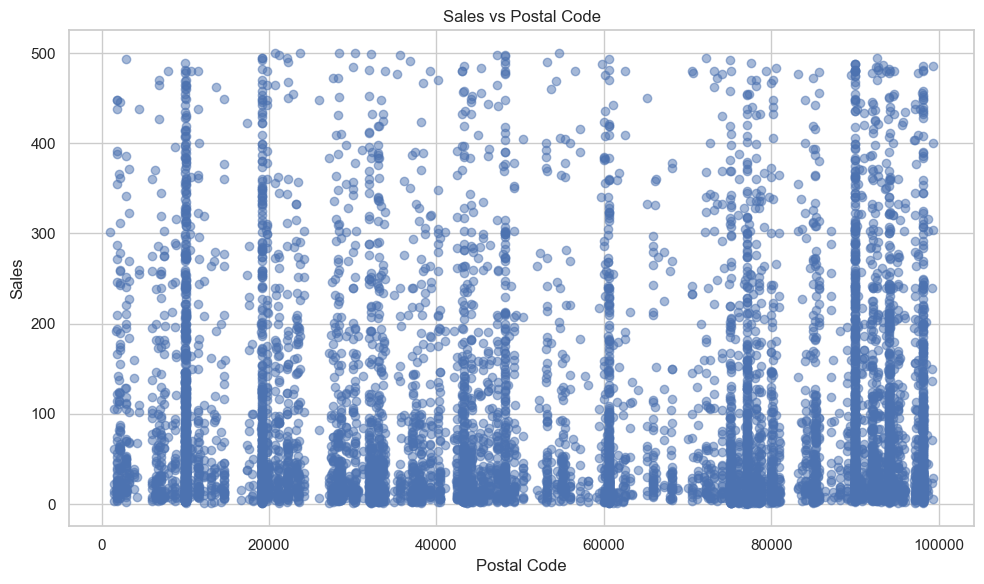

In [18]:
plt.figure(figsize=(10,6))
plt.scatter(df["Postal Code"], df["Sales"], alpha=0.5)
plt.title("Sales vs Postal Code")
plt.xlabel("Postal Code")
plt.ylabel("Sales")
plt.tight_layout()

plt.savefig("../visualizations/scatter_plot.png")

plt.show()

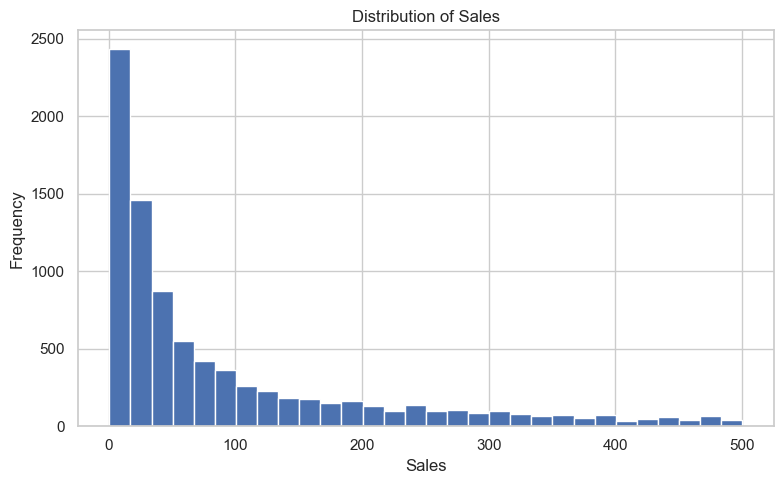

In [19]:
plt.figure(figsize=(8,5))
plt.hist(df["Sales"], bins=30)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.tight_layout()

plt.savefig("../visualizations/histogram.png")

plt.show()

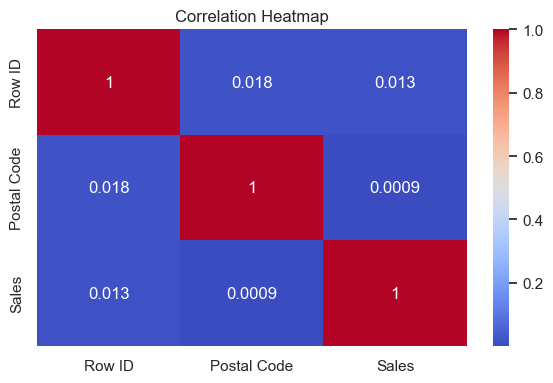

In [20]:
numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(6,4))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()

plt.savefig("../visualizations/heatmap.png")

plt.show()

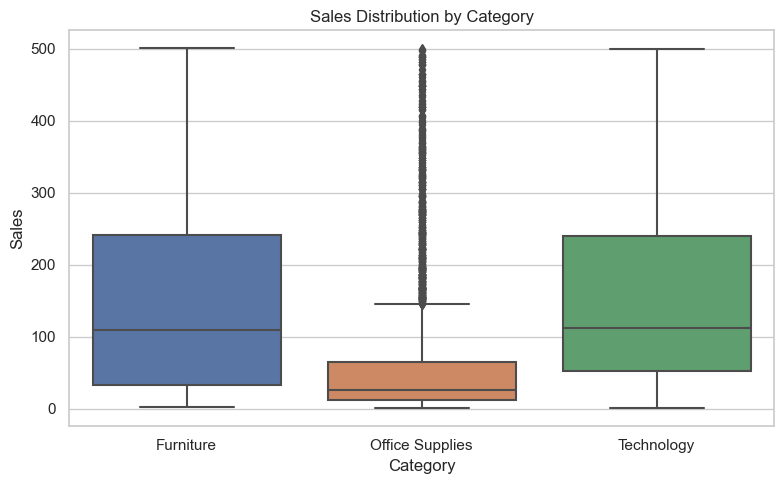

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Category", y="Sales", data=df)

plt.title("Sales Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.tight_layout()

plt.savefig("../visualizations/boxplot.png")

plt.show()

In [22]:
region_sales = df.groupby("Region")["Sales"].sum().reset_index()

fig = px.bar(
    region_sales,
    x="Region",
    y="Sales",
    color="Region",
    title="Sales by Region"
)

fig.write_html("../visualizations/plotly_chart.html")

fig.show()